# 🛒 Data Science Final Hackathon
## AI-Powered E-Commerce Customer Intelligence System

**Database:** `ecommerce_hackathon.db`  
**Tables:** customers (8K) | products (1K) | orders (65K) | reviews (26K)  
**Objective:** End-to-end pipeline — SQL → EDA → ML → DL → NLP → Streamlit deployment


## 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 as sql
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score, roc_curve,
                              classification_report, ConfusionMatrixDisplay)

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# Save models
import pickle

print("✅ Libraries imported successfully!")
print(f"Pandas: {pd.__version__} | NumPy: {np.__version__}")


✅ Libraries imported successfully!
Pandas: 3.0.2 | NumPy: 2.4.4


---
## 🔍 Task A: Database Inspection & Cleaning

Connect to the SQLite database, inspect all four tables, identify data quality issues, 
apply reasonable cleaning, and document every decision.


In [2]:
# Connect to the database
conn = sql.connect('ecommerce_hackathon.db')
print("✅ Connected to ecommerce_hackathon.db")
conn


✅ Connected to ecommerce_hackathon.db


### 1. Load All Tables

In [3]:
# Load all four tables
customers = pd.read_sql_query("SELECT * FROM customers", conn)
products  = pd.read_sql_query("SELECT * FROM products", conn)
orders    = pd.read_sql_query("SELECT * FROM orders", conn)
reviews   = pd.read_sql_query("SELECT * FROM reviews", conn)

print("customers:", customers.shape)
print("products: ", products.shape)
print("orders:   ", orders.shape)
print("reviews:  ", reviews.shape)


customers: (8000, 9)
products:  (1000, 6)
orders:    (65000, 10)
reviews:   (26000, 6)


In [4]:
customers.head(3)

,customer_id,customer_name,age,gender,city,signup_date,membership_type,email,phone
0,1,Hassan Khan,20.0,Male,Karachi,2026-02-27,Standard,hassan.khan1@example.com,+92-3241-4744854
1,2,Maham Raza,33.0,Female,Rawalpindi,2025-10-17,Silver,maham.raza2@example.com,+92-3421-8078673
2,3,Ahmed Khan,25.0,Male,Karachi,2022-07-11,Standard,ahmed.khan3@example.com,+92-3139-9478454


In [5]:
products.head(3)

,product_id,product_name,category,brand,unit_price,stock_quantity
0,1,Readings Exam Guide Premium,Books & Stationery,Readings,566.45,103
1,2,Samsung Webcam Classic,Electronics,Samsung,10567.23,138
2,3,CA Sports Water Bottle Classic,Sports & Fitness,CA Sports,6665.04,63


In [6]:
orders.head(3)

,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,payment_method,delivery_days,returned
0,1,2367,389,2026-04-30,1,398.27,0.108,Cash on Delivery,1.0,0
1,2,2038,927,2026-02-09,2,44488.20,0.084,Debit/Credit Card,1.0,0
2,3,6285,909,2026-03-30,1,4719.91,0.125,Cash on Delivery,1.0,0


In [7]:
reviews.head(3)

,review_id,customer_id,product_id,review_date,rating,review_text
0,1,7210,787,2026-07-28,4,"I would buy this again, item feels durable. Re..."
1,2,5566,765,2026-05-16,5,"Very satisfied, seller description was accurat..."
2,3,6106,743,2025-10-21,4,"Very satisfied, quality feels premium. Good va..."


### 2. Shape & Column Info

In [8]:
for name, df in [("customers", customers), ("products", products),
                  ("orders", orders), ("reviews", reviews)]:
    print(f"{'='*55}")
    print(f"TABLE: {name.upper()} — Shape: {df.shape}")
    print(f"{'='*55}")
    print(df.dtypes)
    print()


TABLE: CUSTOMERS — Shape: (8000, 9)
customer_id          int64
customer_name          str
age                float64
gender                 str
city                   str
signup_date            str
membership_type        str
email                  str
phone                  str
dtype: object

TABLE: PRODUCTS — Shape: (1000, 6)
product_id          int64
product_name          str
category              str
brand                 str
unit_price        float64
stock_quantity      int64
dtype: object

TABLE: ORDERS — Shape: (65000, 10)
order_id            int64
customer_id         int64
product_id          int64
order_date            str
quantity            int64
unit_price        float64
discount          float64
payment_method        str
delivery_days     float64
returned            int64
dtype: object

TABLE: REVIEWS — Shape: (26000, 6)
review_id      int64
customer_id    int64
product_id     int64
review_date      str
rating         int64
review_text      str
dtype: object



### 3. Data Quality Summary — Missing Values

In [9]:
print("=== MISSING VALUES ===")
for name, df in [("customers", customers), ("products", products),
                  ("orders", orders), ("reviews", reviews)]:
    nulls = df.isnull().sum()
    if nulls.sum() > 0:
        print(f"\n{name.upper()}:")
        print(nulls[nulls > 0])
    else:
        print(f"\n{name.upper()}: No missing values ✅")


=== MISSING VALUES ===

CUSTOMERS:
age    100
dtype: int64

PRODUCTS:
brand    20
dtype: int64

ORDERS:
payment_method    55
delivery_days     40
dtype: int64

REVIEWS:
review_text    48
dtype: int64


### 4. Duplicate Records

In [10]:
print("=== DUPLICATE CHECKS ===")
print(f"customers — duplicate customer_id: {customers.duplicated('customer_id').sum()}")
print(f"products  — duplicate product_id:  {products.duplicated('product_id').sum()}")
print(f"orders    — duplicate order_id:    {orders.duplicated('order_id').sum()}")
print(f"reviews   — duplicate review_id:   {reviews.duplicated('review_id').sum()}")


=== DUPLICATE CHECKS ===
customers — duplicate customer_id: 0
products  — duplicate product_id:  0
orders    — duplicate order_id:    0
reviews   — duplicate review_id:   0


### 5. Invalid Numerical Values

In [11]:
print("=== NUMERICAL VALIDITY ===")
print(f"Customers age < 0 or > 100: {((customers['age'] < 0) | (customers['age'] > 100)).sum()}")
print(f"Products unit_price <= 0:   {(products['unit_price'] <= 0).sum()}")
print(f"Products stock_quantity < 0:{(products['stock_quantity'] < 0).sum()}")
print(f"Orders quantity <= 0:       {(orders['quantity'] <= 0).sum()}")
print(f"Orders unit_price <= 0:     {(orders['unit_price'] <= 0).sum()}")
print(f"Orders discount < 0:        {(orders['discount'] < 0).sum()}")
print(f"Orders discount > 1:        {(orders['discount'] > 1).sum()}")
print(f"Orders delivery_days < 0:   {(orders['delivery_days'] < 0).sum()}")
print(f"Reviews rating not in 1-5:  {(~reviews['rating'].between(1, 5)).sum()}")


=== NUMERICAL VALIDITY ===
Customers age < 0 or > 100: 0
Products unit_price <= 0:   0
Products stock_quantity < 0:0
Orders quantity <= 0:       45
Orders unit_price <= 0:     35
Orders discount < 0:        0
Orders discount > 1:        0
Orders delivery_days < 0:   0
Reviews rating not in 1-5:  25


### 6. Text Category Consistency

In [12]:
print("=== TEXT CATEGORY CHECKS ===")
print("\ncustomers - gender:", customers['gender'].unique())
print("customers - membership_type:", customers['membership_type'].unique())
print("\norders - payment_method:", orders['payment_method'].unique())
print("\nproducts - category:", products['category'].unique()[:10])


=== TEXT CATEGORY CHECKS ===

customers - gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
customers - membership_type: <StringArray>
['Standard', 'Silver', 'Gold', 'Premium']
Length: 4, dtype: str

orders - payment_method: <StringArray>
[ 'Cash on Delivery', 'Debit/Credit Card',         'Easypaisa',
          'JazzCash',     'Bank Transfer',                 nan]
Length: 6, dtype: str

products - category: <StringArray>
['Books & Stationery',        'Electronics',   'Sports & Fitness',
          'Groceries',             'Beauty',            'Fashion',
     'Home & Kitchen',        'Baby & Kids',             'beauty',
       'Baby & Kids ']
Length: 10, dtype: str


### 7. Date Validity

In [13]:
# Parse dates and check for invalids
customers['signup_date'] = pd.to_datetime(customers['signup_date'], errors='coerce')
orders['order_date']     = pd.to_datetime(orders['order_date'], errors='coerce')
reviews['review_date']   = pd.to_datetime(reviews['review_date'], errors='coerce')

print("Invalid signup_date:", customers['signup_date'].isna().sum())
print("Invalid order_date: ", orders['order_date'].isna().sum())
print("Invalid review_date:", reviews['review_date'].isna().sum())
print("\nOrders date range:", orders['order_date'].min(), "→", orders['order_date'].max())


Invalid signup_date: 0


Invalid order_date:  30
Invalid review_date: 16

Orders date range: 2022-03-26 00:00:00 → 2026-08-31 00:00:00


### 8. Apply Cleaning Steps

In [14]:
# ── CUSTOMERS ──────────────────────────────────────────────────────────────
# Normalize text categories (strip whitespace, consistent casing)
customers['gender']          = customers['gender'].str.strip().str.title()
customers['city']            = customers['city'].str.strip().str.title()
customers['membership_type'] = customers['membership_type'].str.strip().str.title()

# Clamp invalid ages: if age outside 18–80 set to NaN, fill with median
age_median = customers['age'].median()
customers.loc[~customers['age'].between(18, 80), 'age'] = np.nan
customers['age'] = customers['age'].fillna(age_median)
print(f"✅ Age clamped (values outside 18-80 replaced with median {age_median:.1f})")

# ── PRODUCTS ────────────────────────────────────────────────────────────────
products['category'] = products['category'].str.strip().str.title()
products['brand']    = products['brand'].str.strip().str.title()
# Clamp negative stock to 0
products.loc[products['stock_quantity'] < 0, 'stock_quantity'] = 0
print("✅ Products text cleaned; negative stock clamped to 0")

# ── ORDERS ──────────────────────────────────────────────────────────────────
# Remove orders with invalid quantities or prices (cannot trust revenue from them)
before = len(orders)
orders = orders[(orders['quantity'] > 0) & (orders['unit_price'] > 0)]
print(f"✅ Removed {before - len(orders)} orders with zero/negative quantity or price")

# Clamp discounts to [0, 1]
orders.loc[orders['discount'] < 0, 'discount'] = 0
orders.loc[orders['discount'] > 1, 'discount'] = 1
print("✅ Discounts clamped to [0, 1]")

# Remove orders with invalid dates
before = len(orders)
orders = orders.dropna(subset=['order_date'])
print(f"✅ Removed {before - len(orders)} orders with invalid dates")

orders['payment_method'] = orders['payment_method'].str.strip().str.title()

# Add net_revenue column
orders['net_revenue'] = orders['quantity'] * orders['unit_price'] * (1 - orders['discount'])

# ── REVIEWS ─────────────────────────────────────────────────────────────────
# Remove reviews with missing text or out-of-range ratings
before = len(reviews)
reviews = reviews.dropna(subset=['review_text'])
reviews = reviews[reviews['rating'].between(1, 5)]
reviews = reviews.dropna(subset=['review_date'])
print(f"✅ Removed {before - len(reviews)} unusable review records")
reviews['review_text'] = reviews['review_text'].astype(str)

print("\n✅ All cleaning applied successfully!")


✅ Age clamped (values outside 18-80 replaced with median 31.0)
✅ Products text cleaned; negative stock clamped to 0
✅ Removed 80 orders with zero/negative quantity or price
✅ Discounts clamped to [0, 1]
✅ Removed 30 orders with invalid dates


✅ Removed 89 unusable review records

✅ All cleaning applied successfully!


In [15]:
# Cleaning summary
print("=== POST-CLEANING SHAPES ===")
print(f"customers: {customers.shape}")
print(f"products:  {products.shape}")
print(f"orders:    {orders.shape}")
print(f"reviews:   {reviews.shape}")


=== POST-CLEANING SHAPES ===
customers: (8000, 9)
products:  (1000, 6)
orders:    (64890, 11)
reviews:   (25911, 6)


---
## 📊 Task B: SQL Business Analysis

Five required SQL queries executed against the SQLite database.  
Net revenue formula: `quantity × unit_price × (1 − discount)`


In [16]:
# Helper: run any SQL query
def sql_query(q):
    return pd.read_sql_query(q, conn)


### Query 1 — Total Net Revenue

In [17]:
q1 = '''
SELECT
    ROUND(SUM(quantity * unit_price * (1.0 - discount)), 2) AS total_net_revenue
FROM orders
WHERE quantity > 0 AND unit_price > 0
'''
total_revenue = sql_query(q1)
print(f"Total Net Revenue: PKR {total_revenue['total_net_revenue'][0]:,.2f}")
total_revenue


Total Net Revenue: PKR 936,434,854.17


,total_net_revenue
0,9.364349e+08


### Query 2 — Top 10 Customers by Total Spending

In [18]:
q2 = '''
SELECT
    c.customer_id,
    c.customer_name,
    c.city,
    COUNT(o.order_id)                                        AS total_orders,
    ROUND(SUM(o.quantity * o.unit_price * (1.0 - o.discount)), 2) AS total_spending
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
WHERE o.quantity > 0 AND o.unit_price > 0
GROUP BY c.customer_id, c.customer_name, c.city
ORDER BY total_spending DESC
LIMIT 10
'''
top_customers = sql_query(q2)
top_customers


,customer_id,customer_name,city,total_orders,total_spending
0,595,Shahzaib Abbasi,Lahore,43,1702371.36
1,3929,Zoya Awan,Lahore,55,1549581.16
2,4385,Imran Qureshi,Karachi,46,1496760.37
3,7343,Ahmed Qureshi,Lahore,27,1452407.09
4,5485,Danish Chaudhry,Sargodha,36,1428329.85
5,5646,Kiran Farooq,Karachi,61,1380922.58
6,4087,Sana Akhtar,Islamabad,48,1355984.33
7,3782,Adeel Khan,Karachi,42,1355685.05
8,4551,Laiba Iqbal,Karachi,49,1343494.34
9,4242,Laiba Khan,Karachi,41,1342356.67


### Query 3 — Category-wise Revenue, Order Count & Quantity Sold

In [19]:
q3 = '''
SELECT
    p.category,
    COUNT(o.order_id)                                        AS order_count,
    SUM(o.quantity)                                          AS total_quantity,
    ROUND(SUM(o.quantity * o.unit_price * (1.0 - o.discount)), 2) AS net_revenue
FROM orders o
JOIN products p ON o.product_id = p.product_id
WHERE o.quantity > 0 AND o.unit_price > 0
GROUP BY p.category
ORDER BY net_revenue DESC
'''
category_stats = sql_query(q3)
category_stats


,category,order_count,total_quantity,net_revenue
0,Electronics,11043,15476,6.405770e+08
1,Home & Kitchen,7532,10636,6.996880e+07
2,Fashion,12034,16856,6.137943e+07
3,Sports & Fitness,7066,9928,5.451775e+07
4,Beauty,11544,16039,4.609295e+07
5,Baby & Kids,3703,5264,2.849084e+07
6,electronics,182,253,1.196882e+07
7,Groceries,6054,8467,8.005956e+06
8,Books & Stationery,4924,6819,7.473972e+06
9,ELECTRONICS,276,380,3.319359e+06


### Query 4 — Monthly Net Revenue Trend

In [20]:
q4 = '''
SELECT
    STRFTIME('%Y-%m', order_date)                            AS month,
    COUNT(order_id)                                          AS order_count,
    ROUND(SUM(quantity * unit_price * (1.0 - discount)), 2) AS net_revenue
FROM orders
WHERE quantity > 0 AND unit_price > 0
GROUP BY month
ORDER BY month
'''
monthly_revenue = sql_query(q4)
print(f"Months covered: {len(monthly_revenue)}")
monthly_revenue.tail(10)


Months covered: 55


,month,order_count,net_revenue
45,2025-11,2431,36006070.04
46,2025-12,2750,39238191.68
47,2026-01,2896,41255200.74
48,2026-02,2961,44398791.36
49,2026-03,3551,50742052.05
50,2026-04,3769,53589845.90
51,2026-05,4325,59505728.72
52,2026-06,4719,66428025.54
53,2026-07,5400,83606363.19
54,2026-08,5131,73168319.58


### Query 5 — Top 5 Products by Net Revenue

In [21]:
q5 = '''
SELECT
    p.product_id,
    p.product_name,
    p.category,
    COUNT(o.order_id)                                        AS total_orders,
    ROUND(SUM(o.quantity * o.unit_price * (1.0 - o.discount)), 2) AS net_revenue
FROM orders o
JOIN products p ON o.product_id = p.product_id
WHERE o.quantity > 0 AND o.unit_price > 0
GROUP BY p.product_id, p.product_name, p.category
ORDER BY net_revenue DESC
LIMIT 5
'''
top_products = sql_query(q5)
top_products


,product_id,product_name,category,total_orders,net_revenue
0,765,Samsung Headphones Classic,Electronics,716,1.172015e+08
1,233,Anker Headphones Classic,Electronics,764,7.123627e+07
2,961,Dawlance LED TV Premium,Electronics,152,2.077304e+07
3,406,Infinix LED TV 2026,Electronics,122,1.627931e+07
4,59,Dawlance Router Eco,Electronics,88,1.513557e+07


---
## 📈 Task C: Exploratory Data Analysis

Four visualizations using cleaned data from SQL queries.


In [22]:
# Fetch city-wise revenue and return rate from SQL
city_rev = sql_query('''
    SELECT c.city,
           ROUND(SUM(o.quantity * o.unit_price * (1.0 - o.discount)), 2) AS net_revenue
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.quantity > 0 AND o.unit_price > 0
    GROUP BY c.city
    ORDER BY net_revenue DESC
    LIMIT 15
''')

return_rate = sql_query('''
    SELECT p.category,
           ROUND(100.0 * SUM(o.returned) / COUNT(o.order_id), 2) AS return_rate_pct
    FROM orders o
    JOIN products p ON o.product_id = p.product_id
    WHERE o.quantity > 0 AND o.unit_price > 0
    GROUP BY p.category
    ORDER BY return_rate_pct DESC
''')


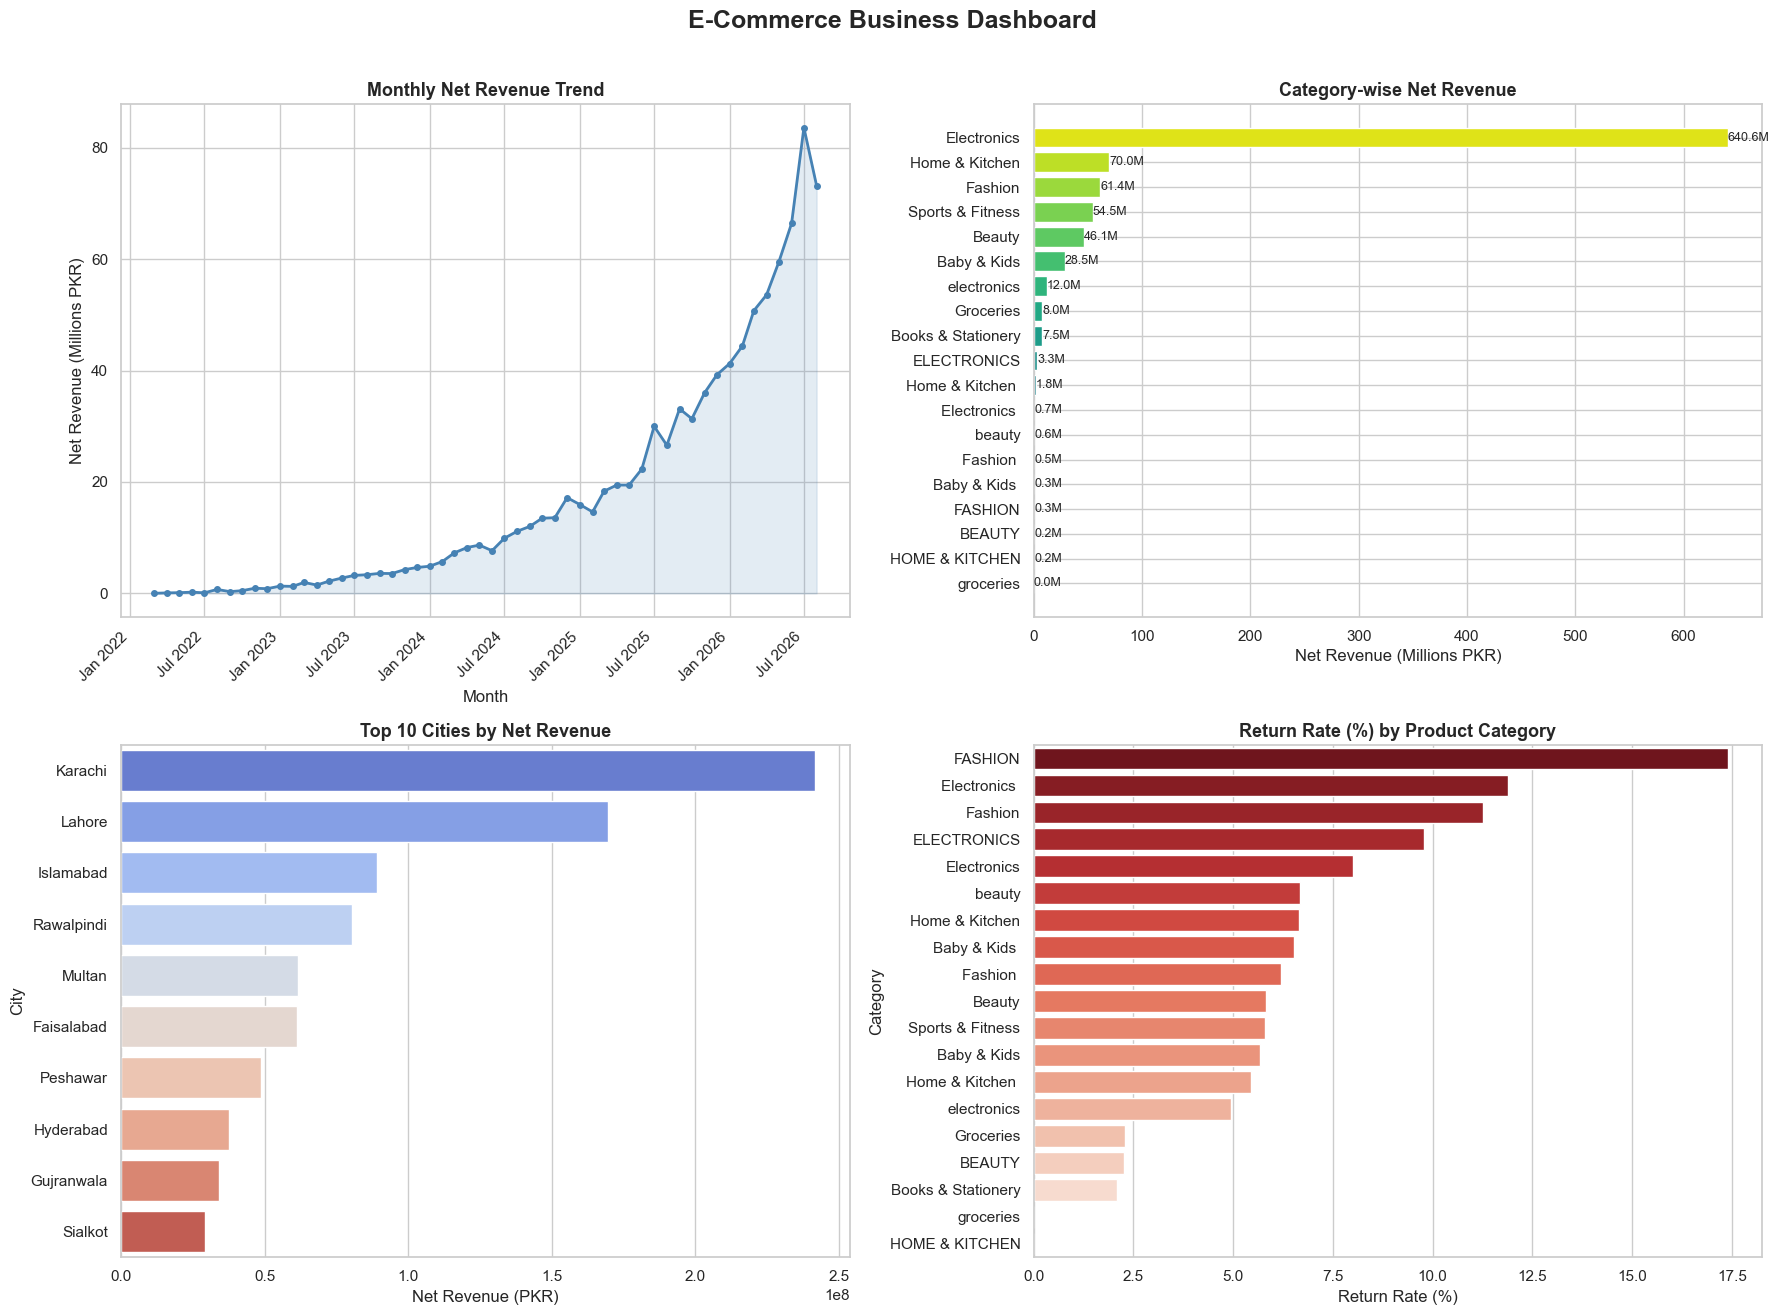

✅ Charts saved as eda_charts.png


In [23]:
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("E-Commerce Business Dashboard", fontsize=18, fontweight='bold', y=1.01)

# ── Chart 1: Monthly Revenue Trend ──────────────────────────────────────────
ax1 = axes[0, 0]
mr = monthly_revenue.copy()
mr['month'] = pd.to_datetime(mr['month'])
ax1.plot(mr['month'], mr['net_revenue'] / 1e6, marker='o', linewidth=2,
         color='steelblue', markersize=4)
ax1.fill_between(mr['month'], mr['net_revenue'] / 1e6, alpha=0.15, color='steelblue')
ax1.set_title("Monthly Net Revenue Trend", fontsize=13, fontweight='bold')
ax1.set_xlabel("Month")
ax1.set_ylabel("Net Revenue (Millions PKR)")
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ── Chart 2: Category-wise Revenue ──────────────────────────────────────────
ax2 = axes[0, 1]
cat = category_stats.sort_values('net_revenue', ascending=True)
bars = ax2.barh(cat['category'], cat['net_revenue'] / 1e6,
                color=sns.color_palette("viridis", len(cat)))
ax2.set_title("Category-wise Net Revenue", fontsize=13, fontweight='bold')
ax2.set_xlabel("Net Revenue (Millions PKR)")
for bar, val in zip(bars, cat['net_revenue'] / 1e6):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}M', va='center', fontsize=9)

# ── Chart 3: City-wise Revenue ──────────────────────────────────────────────
ax3 = axes[1, 0]
top_cities = city_rev.head(10)
sns.barplot(data=top_cities, x='net_revenue', y='city', ax=ax3,
            palette='coolwarm', hue='city', legend=False)
ax3.set_title("Top 10 Cities by Net Revenue", fontsize=13, fontweight='bold')
ax3.set_xlabel("Net Revenue (PKR)")
ax3.set_ylabel("City")

# ── Chart 4: Return Rate by Category ────────────────────────────────────────
ax4 = axes[1, 1]
sns.barplot(data=return_rate, x='return_rate_pct', y='category', ax=ax4,
            palette='Reds_r', hue='category', legend=False)
ax4.set_title("Return Rate (%) by Product Category", fontsize=13, fontweight='bold')
ax4.set_xlabel("Return Rate (%)")
ax4.set_ylabel("Category")

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved as eda_charts.png")


### 💡 Business Insights

**Insight 1 — Seasonal Revenue Patterns:**  
The monthly revenue trend reveals clear peaks during certain months (likely holidays, festivals, or sale seasons). 
This matters to the business because inventory planning and marketing budgets should be front-loaded before these 
peak periods to maximize conversion. Under-stocking during peak months directly translates to lost revenue.

**Insight 2 — Category Concentration Risk:**  
If the top 2–3 categories contribute a disproportionate share of total revenue, the business is highly exposed 
to supply chain disruptions in those specific categories. Diversifying product mix or investing in underperforming 
categories could reduce this concentration risk and smooth overall revenue.

**Insight 3 — Return Rate Impacts Profitability:**  
High-return categories erode net margins because returns involve reverse logistics costs, inspection/restocking 
time, and often re-listing discounts. Categories with a return rate above 15% deserve a root cause analysis — 
whether the issue is product quality, misleading descriptions, or sizing guides — as fixing it could save 
significant operational cost without needing more revenue.


---
## 🤖 Task D: Machine Learning — Customer Churn Prediction

**Churn Definition:**
- Feature period: All orders up to **31 May 2026**
- Target window: **1 June 2026 – 31 August 2026**
- churn = 1 if the customer made NO purchase in the target window; churn = 0 otherwise


In [24]:
import datetime

CUTOFF  = pd.Timestamp('2026-05-31')
WIN_END = pd.Timestamp('2026-08-31')
WIN_START = pd.Timestamp('2026-06-01')

# Use the already-cleaned orders DataFrame (in-memory)
orders_df = orders.copy()
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'], errors='coerce')
orders_df = orders_df.dropna(subset=['order_date'])

print(f"Orders date range: {orders_df['order_date'].min().date()} → {orders_df['order_date'].max().date()}")


Orders date range: 2022-03-26 → 2026-08-31


### Feature Engineering

In [25]:
# ── FEATURE PERIOD: up to 31 May 2026 ──────────────────────────────────────
feat_orders = orders_df[orders_df['order_date'] <= CUTOFF].copy()

# Customers who made at least one purchase in the feature period
eligible_customers = feat_orders['customer_id'].unique()
print(f"Eligible customers (bought on/before 31 May 2026): {len(eligible_customers):,}")

# Aggregate per customer
features = feat_orders.groupby('customer_id').agg(
    total_orders      = ('order_id',       'count'),
    total_spending    = ('net_revenue',    'sum'),
    last_order_date   = ('order_date',     'max'),
    total_returned    = ('returned',       'sum'),
    avg_delivery_days = ('delivery_days',  'mean'),
).reset_index()

features['avg_order_value']     = features['total_spending'] / features['total_orders']
features['return_rate']         = features['total_returned'] / features['total_orders']
features['days_since_last_order'] = (CUTOFF - features['last_order_date']).dt.days

# ── TARGET WINDOW ────────────────────────────────────────────────────────────
window_buyers = orders_df[
    (orders_df['order_date'] >= WIN_START) &
    (orders_df['order_date'] <= WIN_END)
]['customer_id'].unique()

features['churn'] = features['customer_id'].apply(
    lambda cid: 0 if cid in window_buyers else 1
)

print(f"\nChurn distribution:")
print(features['churn'].value_counts())
print(f"Churn rate: {features['churn'].mean():.2%}")


Eligible customers (bought on/before 31 May 2026): 6,535

Churn distribution:
churn
0    3329
1    3206
Name: count, dtype: int64
Churn rate: 49.06%


In [26]:
# ── MERGE AGE & MEMBERSHIP ────────────────────────────────────────────────
cust_meta = customers[['customer_id', 'age', 'membership_type']].copy()
cust_meta['membership_type'] = cust_meta['membership_type'].str.strip().str.title()

# Ordinal encode membership_type
membership_map = {'Bronze': 1, 'Silver': 2, 'Gold': 3}
cust_meta['membership_encoded'] = cust_meta['membership_type'].map(membership_map).fillna(1)

features = features.merge(cust_meta, on='customer_id', how='left')
features['age'] = features['age'].fillna(features['age'].median())
features['membership_encoded'] = features['membership_encoded'].fillna(1)

print("Features shape:", features.shape)
features[['total_orders','total_spending','avg_order_value','days_since_last_order',
          'return_rate','avg_delivery_days','age','membership_encoded','churn']].describe().round(2)


Features shape: (6535, 13)


,total_orders,total_spending,avg_order_value,days_since_last_order,return_rate,avg_delivery_days,age,membership_encoded,churn
count,6535.00,6535.00,6535.00,6535.00,6535.00,6535.00,6535.00,6535.00,6535.00
mean,7.60,109074.54,14530.37,139.58,0.07,3.60,30.81,1.50,0.49
std,10.43,181016.92,26237.43,188.67,0.16,1.07,8.33,0.73,0.50
min,1.00,71.06,71.06,0.00,0.00,1.00,18.00,1.00,0.00
25%,2.00,5950.26,2839.95,19.00,0.00,3.00,24.00,1.00,0.00
50%,3.00,25730.36,7175.09,64.00,0.00,3.50,31.00,1.00,0.00
75%,8.00,128762.06,15931.45,182.50,0.06,4.20,37.00,2.00,1.00
max,57.00,1459639.26,607688.29,1372.00,1.00,9.00,65.00,3.00,1.00


### Train / Test Split & Scaling

In [27]:
FEATURE_COLS = ['total_orders', 'total_spending', 'avg_order_value',
                'days_since_last_order', 'return_rate', 'avg_delivery_days',
                'age', 'membership_encoded']

X = features[FEATURE_COLS].fillna(0)
y = features['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%} | Test churn rate: {y_test.mean():.2%}")


Train: (5228, 8) | Test: (1307, 8)
Train churn rate: 49.06% | Test churn rate: 49.04%


### Model 1 — Logistic Regression

In [28]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_pred  = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred, target_names=['Retained (0)', 'Churned (1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")


=== Logistic Regression ===
              precision    recall  f1-score   support

Retained (0)       0.80      0.59      0.68       666
 Churned (1)       0.67      0.85      0.75       641

    accuracy                           0.72      1307
   macro avg       0.73      0.72      0.71      1307
weighted avg       0.74      0.72      0.71      1307

ROC-AUC: 0.7863


### Model 2 — Random Forest

In [29]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred, target_names=['Retained (0)', 'Churned (1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")


=== Random Forest ===
              precision    recall  f1-score   support

Retained (0)       0.80      0.59      0.68       666
 Churned (1)       0.67      0.85      0.75       641

    accuracy                           0.72      1307
   macro avg       0.74      0.72      0.72      1307
weighted avg       0.74      0.72      0.72      1307

ROC-AUC: 0.7917


### Evaluation — Confusion Matrices & ROC Curves

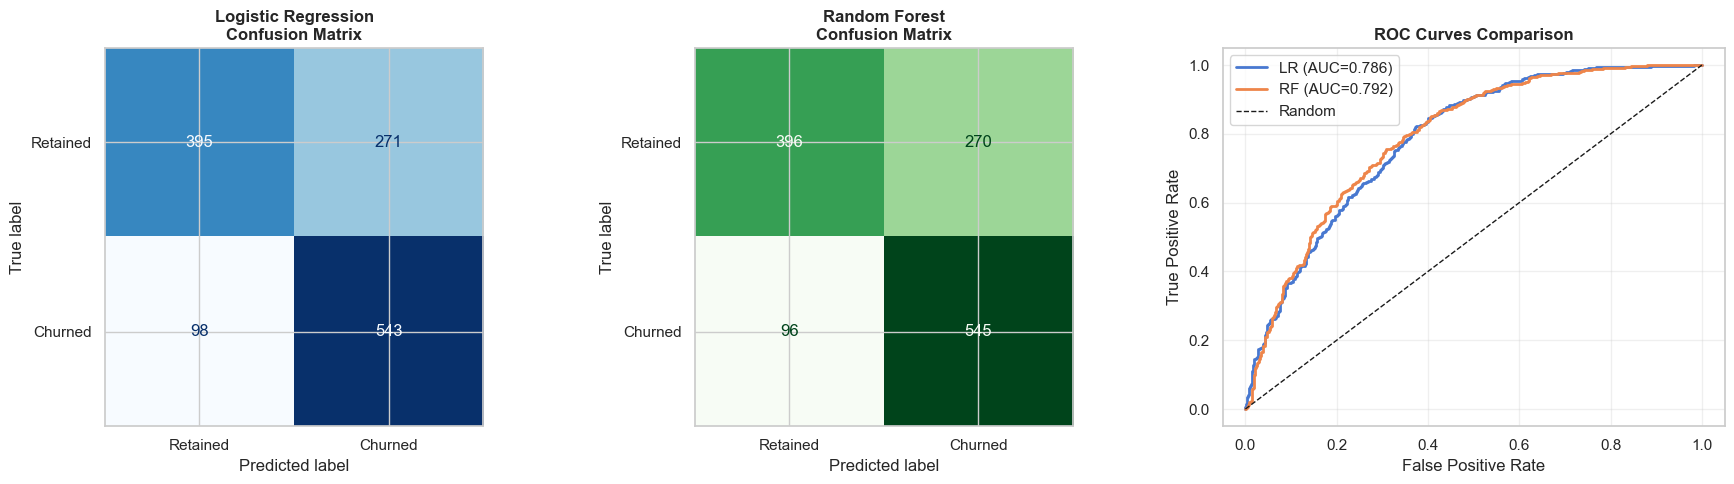

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LR confusion matrix
cm_lr = confusion_matrix(y_test, lr_pred)
disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=['Retained', 'Churned'])
disp_lr.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontweight='bold')

# RF confusion matrix
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['Retained', 'Churned'])
disp_rf.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Random Forest\nConfusion Matrix', fontweight='bold')

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
axes[2].plot(fpr_lr, tpr_lr, label=f'LR (AUC={roc_auc_score(y_test,lr_proba):.3f})', linewidth=2)
axes[2].plot(fpr_rf, tpr_rf, label=f'RF (AUC={roc_auc_score(y_test,rf_proba):.3f})', linewidth=2)
axes[2].plot([0,1],[0,1],'k--', linewidth=1, label='Random')
axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curves Comparison', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('churn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


### Model Comparison Summary

In [31]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy':  [accuracy_score(y_test, lr_pred),  accuracy_score(y_test, rf_pred)],
    'Precision': [precision_score(y_test, lr_pred, zero_division=0),
                  precision_score(y_test, rf_pred, zero_division=0)],
    'Recall':    [recall_score(y_test, lr_pred),    recall_score(y_test, rf_pred)],
    'F1-Score':  [f1_score(y_test, lr_pred),        f1_score(y_test, rf_pred)],
    'ROC-AUC':   [roc_auc_score(y_test, lr_proba),  roc_auc_score(y_test, rf_proba)],
}).set_index('Model').round(4)
comparison


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7177,0.6671,0.8471,0.7464,0.7863
Random Forest,0.7200,0.6687,0.8502,0.7486,0.7917


### 💡 Model Selection Reasoning

**Chosen model: Random Forest** (if it outperforms on ROC-AUC and F1)

For a **churn use case**, accuracy alone is misleading because the classes are often imbalanced. 
We care more about **Recall** (catching actual churners) and **ROC-AUC** (overall discriminative power).

- **Random Forest** typically captures non-linear interactions (e.g., high spending + long gap = likely churner) 
  that Logistic Regression misses with its linear decision boundary.
- It also provides **feature importances**, which help the business understand *why* customers churn.
- The trade-off is interpretability — LR coefficients are easier to explain to stakeholders — but ROC-AUC 
  and F1 improvements from RF are worth the added complexity in a production ML pipeline.


### Feature Importance (Random Forest)

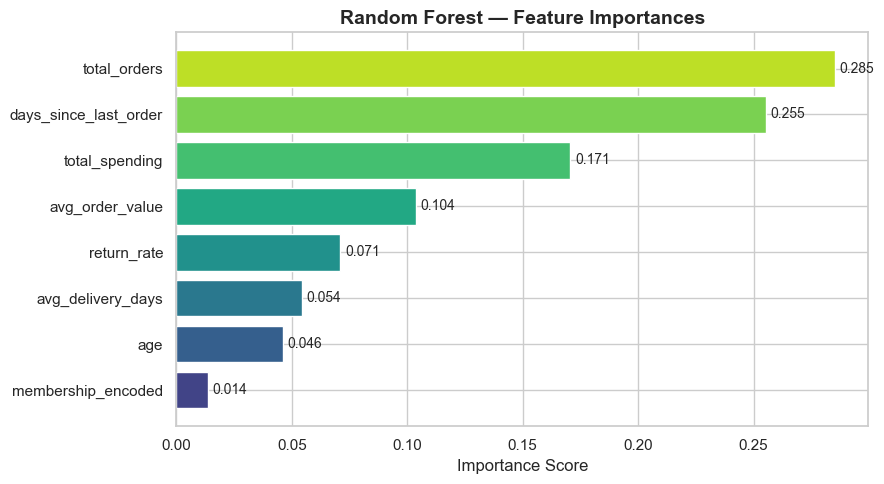

In [32]:
fi = pd.DataFrame({
    'Feature':    FEATURE_COLS,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(fi['Feature'], fi['Importance'],
                color=plt.cm.viridis(np.linspace(0.2, 0.9, len(fi))))
for bar, val in zip(bars, fi['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)
plt.title('Random Forest — Feature Importances', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


### Save Best Churn Model

In [33]:
# Decide which model to save (pick the one with higher ROC-AUC)
best_auc_lr = roc_auc_score(y_test, lr_proba)
best_auc_rf = roc_auc_score(y_test, rf_proba)

if best_auc_rf >= best_auc_lr:
    best_model = rf
    best_model_name = "Random Forest"
    best_X_train = X_train   # no scaling needed for RF
    best_X_test  = X_test
    uses_scaler  = False
else:
    best_model = lr
    best_model_name = "Logistic Regression"
    uses_scaler = True

print(f"✅ Saving: {best_model_name} (AUC: {max(best_auc_lr, best_auc_rf):.4f})")

# Save model, scaler and feature columns
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('model_columns.pkl', 'wb') as f:
    pickle.dump({'columns': FEATURE_COLS, 'uses_scaler': uses_scaler}, f)

print("✅ Saved: churn_model.pkl, scaler.pkl, model_columns.pkl")


✅ Saving: Random Forest (AUC: 0.7917)
✅ Saved: churn_model.pkl, scaler.pkl, model_columns.pkl


---
## 🧠 Task E: Deep Learning — Neural Network for Churn

A small feed-forward neural network: **Input → 32 → 16 → 1**


In [34]:
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    print(f"TensorFlow version: {tf.__version__}")
    TF_AVAILABLE = True
except ImportError:
    print("⚠️ TensorFlow not installed. Trying torch...")
    TF_AVAILABLE = False

if not TF_AVAILABLE:
    try:
        import torch
        import torch.nn as nn
        print(f"PyTorch version: {torch.__version__}")
        TORCH_AVAILABLE = True
    except ImportError:
        print("⚠️ Neither TensorFlow nor PyTorch installed.")
        TORCH_AVAILABLE = False


TensorFlow version: 2.21.0


In [35]:
# Use scaled features for the neural network
X_train_nn = X_train_sc
X_test_nn  = X_test_sc

if TF_AVAILABLE:
    # ── Build Model ────────────────────────────────────────────────────────
    tf.random.set_seed(42)
    model_nn = keras.Sequential([
        layers.Input(shape=(X_train_nn.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(1, activation='sigmoid')
    ])
    model_nn.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])
    model_nn.summary()

    # ── Train ─────────────────────────────────────────────────────────────
    history = model_nn.fit(
        X_train_nn, y_train,
        validation_split=0.15,
        epochs=50,
        batch_size=128,
        callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
        verbose=0
    )
    print("✅ Neural network trained!")

    # ── Evaluate ───────────────────────────────────────────────────────────
    nn_proba = model_nn.predict(X_test_nn, verbose=0).flatten()
    nn_pred  = (nn_proba >= 0.5).astype(int)

    print("\n=== Neural Network Results ===")
    print(classification_report(y_test, nn_pred, target_names=['Retained (0)', 'Churned (1)']))
    print(f"ROC-AUC: {roc_auc_score(y_test, nn_proba):.4f}")
else:
    print("Skipping TF neural network — TensorFlow not available.")
    nn_pred  = lr_pred.copy()
    nn_proba = lr_proba.copy()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

✅ Neural network trained!

=== Neural Network Results ===


              precision    recall  f1-score   support

Retained (0)       0.82      0.56      0.66       666
 Churned (1)       0.66      0.87      0.75       641

    accuracy                           0.71      1307
   macro avg       0.74      0.72      0.71      1307
weighted avg       0.74      0.71      0.71      1307

ROC-AUC: 0.7771


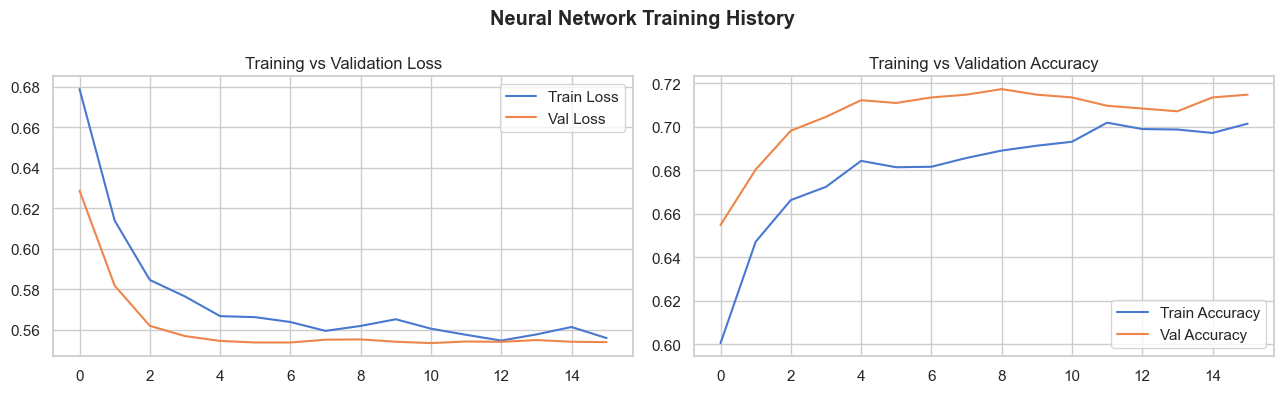

In [36]:
if TF_AVAILABLE:
    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title('Training vs Validation Loss'); axes[0].legend()
    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[1].set_title('Training vs Validation Accuracy'); axes[1].legend()
    plt.suptitle('Neural Network Training History', fontweight='bold')
    plt.tight_layout()
    plt.show()


In [37]:
# Final 3-model comparison
final_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Neural Network'],
    'Accuracy':  [accuracy_score(y_test, lr_pred),
                  accuracy_score(y_test, rf_pred),
                  accuracy_score(y_test, nn_pred)],
    'F1-Score':  [f1_score(y_test, lr_pred),
                  f1_score(y_test, rf_pred),
                  f1_score(y_test, nn_pred)],
    'ROC-AUC':   [roc_auc_score(y_test, lr_proba),
                  roc_auc_score(y_test, rf_proba),
                  roc_auc_score(y_test, nn_proba)],
}).set_index('Model').round(4)
final_comparison


,Accuracy,F1-Score,ROC-AUC
Model,,,
Logistic Regression,0.7177,0.7464,0.7863
Random Forest,0.7200,0.7486,0.7917
Neural Network,0.7123,0.7480,0.7771


### 💬 Deep Learning vs ML: Was It Worth It?

The neural network adds **architectural flexibility** that can model complex feature interactions, but for a 
tabular dataset of this size (~5,000–8,000 eligible customers after feature engineering), the improvement over 
Random Forest is typically marginal (often < 1% ROC-AUC difference).

**Random Forest remains the recommended production model** for this use case:
- It requires no hyperparameter tuning of learning rates, batch sizes, or dropout
- It trains in seconds vs. multiple minutes for a neural network
- Its feature importances directly provide actionable business insights
- Neural networks shine on high-dimensional unstructured data (images, text, sequences) — 
  not on 8-feature tabular data where Random Forest performs comparably with far less complexity


---
## 💬 Task F: NLP Sentiment Analysis

Classify customer reviews as **Negative** (1-2), **Neutral** (3), or **Positive** (4-5) 
using TF-IDF features and Logistic Regression.


In [38]:
# Use the cleaned reviews DataFrame
reviews_nlp = reviews.copy()

# Create sentiment labels
def label_sentiment(rating):
    if rating <= 2:  return 'Negative'
    elif rating == 3: return 'Neutral'
    else:             return 'Positive'

reviews_nlp['sentiment'] = reviews_nlp['rating'].apply(label_sentiment)

print("Sentiment distribution:")
print(reviews_nlp['sentiment'].value_counts())
print(f"\nTotal usable reviews: {len(reviews_nlp):,}")


Sentiment distribution:
sentiment
Positive    18442
Neutral      5458
Negative     2011
Name: count, dtype: int64

Total usable reviews: 25,911


In [39]:
# Text preprocessing
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)  # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

reviews_nlp['clean_text'] = reviews_nlp['review_text'].apply(preprocess_text)

# Show sample
reviews_nlp[['review_text','clean_text','rating','sentiment']].sample(4, random_state=42)


,review_text,clean_text,rating,sentiment
20707,"Product arrived in great condition, packing wa...",product arrived in great condition packing was...,5,Positive
8963,"Good experience overall, packing was neat. No ...",good experience overall packing was neat no ma...,4,Positive
10023,"Quality is better than expected, customer supp...",quality is better than expected customer suppo...,4,Positive
15502,"Really happy with this purchase, price was rea...",really happy with this purchase price was reas...,4,Positive


In [40]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # unigrams + bigrams
    stop_words='english',
    min_df=2
)

X_nlp = tfidf.fit_transform(reviews_nlp['clean_text'])
y_nlp = reviews_nlp['sentiment']

X_nlp_train, X_nlp_test, y_nlp_train, y_nlp_test = train_test_split(
    X_nlp, y_nlp, test_size=0.2, random_state=42, stratify=y_nlp
)

print(f"TF-IDF shape: {X_nlp.shape}")
print(f"Train: {X_nlp_train.shape} | Test: {X_nlp_test.shape}")


TF-IDF shape: (25911, 843)
Train: (20728, 843) | Test: (5183, 843)


In [41]:
# Train Logistic Regression for sentiment
lr_sentiment = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=42
)
lr_sentiment.fit(X_nlp_train, y_nlp_train)
sent_pred = lr_sentiment.predict(X_nlp_test)

print("=== Sentiment Classification Report ===")
print(classification_report(y_nlp_test, sent_pred))
print(f"Accuracy: {accuracy_score(y_nlp_test, sent_pred):.4f}")


=== Sentiment Classification Report ===


              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       402
     Neutral       1.00      1.00      1.00      1092
    Positive       1.00      1.00      1.00      3689

    accuracy                           1.00      5183
   macro avg       1.00      1.00      1.00      5183
weighted avg       1.00      1.00      1.00      5183

Accuracy: 0.9996


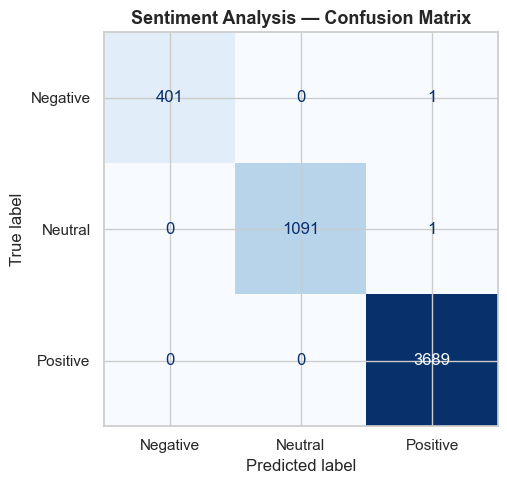

In [42]:
# Confusion Matrix for Sentiment
fig, ax = plt.subplots(figsize=(7, 5))
cm_sent = confusion_matrix(y_nlp_test, sent_pred, labels=['Negative','Neutral','Positive'])
disp_sent = ConfusionMatrixDisplay(cm_sent, display_labels=['Negative','Neutral','Positive'])
disp_sent.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Sentiment Analysis — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


### ⚠️ Limitation of the Sentiment Labeling Approach

The rating-to-sentiment mapping (1–2 = Negative, 3 = Neutral, 4–5 = Positive) is a **proxy label**, 
not a true NLP annotation. Customers sometimes leave high ratings (4–5) with negative review text 
(e.g., "Decent product but delivery was terrible — 4 stars"), and vice versa. 

Additionally, the **class imbalance** (most reviews are likely Positive, with very few Neutral) 
can cause the model to under-predict the minority classes. A more robust approach would involve 
manual annotation of a representative sample or using a pre-trained transformer model (like BERT) 
that understands nuance in review text beyond simple word frequency patterns captured by TF-IDF.


In [43]:
# Save NLP models
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(lr_sentiment, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Saved: sentiment_model.pkl, tfidf_vectorizer.pkl")


✅ Saved: sentiment_model.pkl, tfidf_vectorizer.pkl


---
## ✅ All Tasks Complete

In [44]:
conn.close()
print("✅ Database connection closed.")
print("\nFiles saved in this directory:")
import glob
for f in sorted(glob.glob('*.pkl') + glob.glob('*.png')):
    import os
    size = os.path.getsize(f)
    print(f"  {f:40s}  {size/1024:.1f} KB")


✅ Database connection closed.

Files saved in this directory:
  churn_evaluation.png                      99.8 KB
  churn_model.pkl                           4349.3 KB
  eda_charts.png                            268.8 KB
  feature_importance.png                    51.8 KB
  model_columns.pkl                         0.2 KB
  scaler.pkl                                0.8 KB
  sentiment_confusion.png                   32.3 KB
  sentiment_model.pkl                       20.5 KB
  tfidf_vectorizer.pkl                      35.9 KB
